In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Download Data

In [2]:


# Configuration
sns.set(style="whitegrid")
DATA_PATH = Path("data")

# Fonction de chargement
def load_imdb_data(split="train"):
    texts = []
    labels = []
    for label_type in ["pos", "neg"]:
        dir_path = DATA_PATH / split / label_type
        for fname in os.listdir(dir_path):
            with open(dir_path / fname, encoding="utf-8") as f:
                texts.append(f.read())
                labels.append(1 if label_type == "pos" else 0)
    return pd.DataFrame({"review": texts, "label": labels})

# Chargement des jeux de données
train_df = load_imdb_data("train")
test_df = load_imdb_data("test")




In [3]:
# Aperçu
print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")
display(train_df.sample(3))

Train size: 25000 | Test size: 25000


,review,label
12323,A glacier slide inside a cavernous ice mountai...,1
888,Lars Von Triers Europa is an extremely good fi...,1
289,The first installment of this notorious horror...,1


In [4]:
# Ajout de la longueur de chaque review
train_df["review_length"] = train_df["review"].apply(lambda x: len(x.split()))
test_df["review_length"] = test_df["review"].apply(lambda x: len(x.split()))

C:\Users\Hp\AppData\Local\Temp\ipykernel_21408\3040776543.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Négatif", "Positif"])
C:\Users\Hp\AppData\Local\Temp\ipykernel_21408\3040776543.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Négatif", "Positif"])


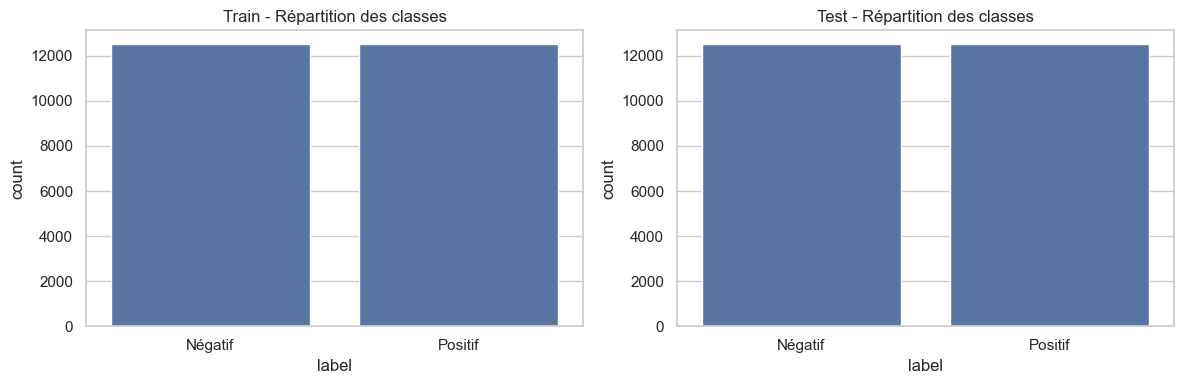

In [5]:
# Répartition des classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=train_df, x="label", ax=axes[0])
axes[0].set_title("Train - Répartition des classes")
axes[0].set_xticklabels(["Négatif", "Positif"])

sns.countplot(data=test_df, x="label", ax=axes[1])
axes[1].set_title("Test - Répartition des classes")
axes[1].set_xticklabels(["Négatif", "Positif"])
plt.tight_layout()
plt.show()


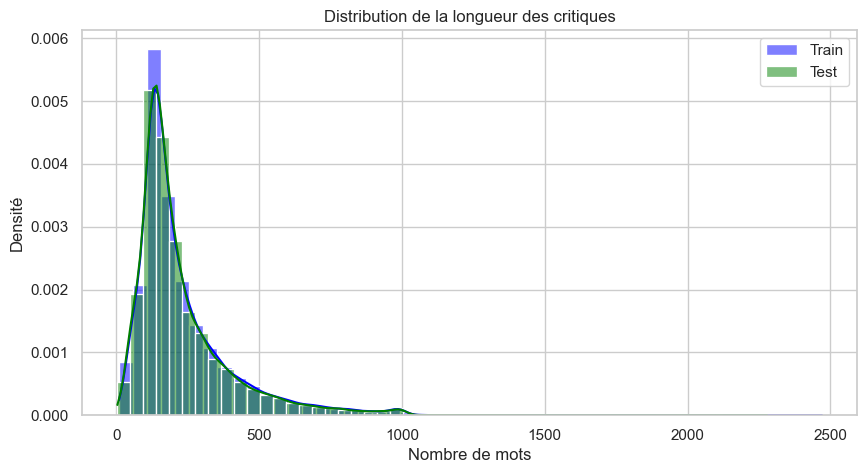

In [6]:
# Distribution des longueurs
plt.figure(figsize=(10, 5))
sns.histplot(train_df["review_length"], color="blue", bins=50, kde=True, label="Train", stat="density")
sns.histplot(test_df["review_length"], color="green", bins=50, kde=True, label="Test", stat="density")
plt.legend()
plt.title("Distribution de la longueur des critiques")
plt.xlabel("Nombre de mots")
plt.ylabel("Densité")
plt.show()

les deux datasets s sont équilibrés, avec une longueur de critique qui suit une distribution similaire.


In [7]:
# Visualisation des critiques les plus longues et les plus courtes  
def plot_extreme_reviews(df, n=5):
    longest_reviews = df.nlargest(n, "review_length")
    shortest_reviews = df.nsmallest(n, "review_length")

    fig, axes = plt.subplots(2, n, figsize=(20, 6))
    for i in range(n):
        axes[0, i].text(0.5, 0.5, longest_reviews.iloc[i]["review"], fontsize=12)
        axes[0, i].set_title(f"Longest Review {i+1}")
        axes[0, i].axis("off")

        axes[1, i].text(0.5, 0.5, shortest_reviews.iloc[i]["review"], fontsize=12)
        axes[1, i].set_title(f"Shortest Review {i+1}")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()
plot_extreme_reviews(train_df, n=3)

C:\Users\Hp\AppData\Local\Temp\ipykernel_21408\2951158443.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


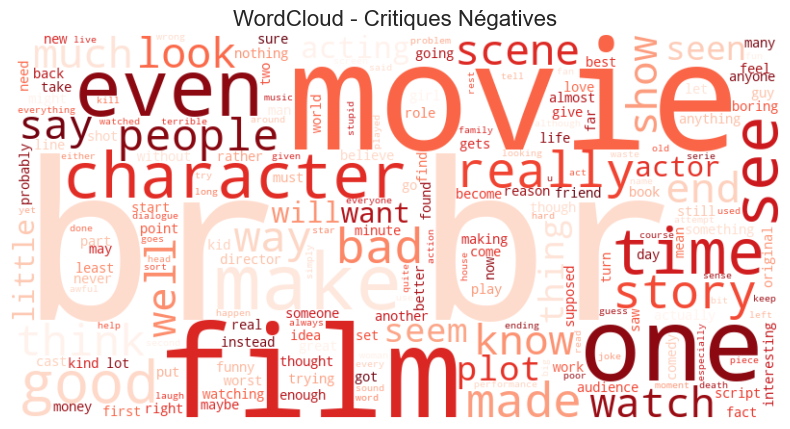

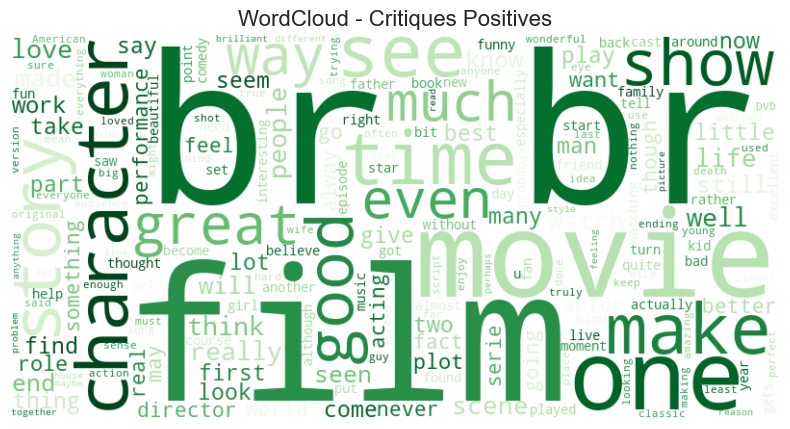

In [9]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Fusionner tous les textes d'une classe
def generate_wordcloud(df, label_value, title, color="black"):
    text = " ".join(df[df["label"] == label_value]["review"].tolist())
    stopwords = set(STOPWORDS)
    wordcloud = WordCloud(width=800, height=400, background_color="white",
                          stopwords=stopwords, colormap=color).generate(text)

    # Affichage
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

# Nuage de mots pour les critiques négatives
generate_wordcloud(train_df, label_value=0, title="WordCloud - Critiques Négatives", color="Reds")

# Nuage de mots pour les critiques positives
generate_wordcloud(train_df, label_value=1, title="WordCloud - Critiques Positives", color="Greens")


mots les plus fréquents

In [11]:
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Fonction pour tokenizer et nettoyer
def preprocess_text(text):
    tokens = nltk.word_tokenize(text.lower())
    return [t for t in tokens if t.isalpha() and t not in stop_words]

# Top mots fréquents pour chaque classe
def plot_top_words(df, label_value, n=20, title=""):
    all_words = []
    for text in df[df["label"] == label_value]["review"]:
        all_words.extend(preprocess_text(text))
    most_common = Counter(all_words).most_common(n)
    words, freqs = zip(*most_common)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(freqs), y=list(words))
    plt.title(title)
    plt.xlabel("Fréquence")
    plt.ylabel("Mots")
    plt.show()

# ⚡ Mots les plus fréquents
plot_top_words(train_df, label_value=0, title="Top mots fréquents - Critiques Négatives")
plot_top_words(train_df, label_value=1, title="Top mots fréquents - Critiques Positives")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - 'C:\\Users\\Hp/nltk_data'
    - 'c:\\Users\\Hp\\AppData\\Local\\Programs\\Python\\Python313\\nltk_data'
    - 'c:\\Users\\Hp\\AppData\\Local\\Programs\\Python\\Python313\\share\\nltk_data'
    - 'c:\\Users\\Hp\\AppData\\Local\\Programs\\Python\\Python313\\lib\\nltk_data'
    - 'C:\\Users\\Hp\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [ ]:
# Fonction pour extraire bigrams les plus fréquents
def plot_top_bigrams(df, label_value, n=20, title=""):
    bigrams = []
    for text in df[df["label"] == label_value]["review"]:
        tokens = preprocess_text(text)
        bigrams.extend(list(ngrams(tokens, 2)))
    most_common = Counter(bigrams).most_common(n)
    bigram_labels = [' '.join(pair) for pair, _ in most_common]
    counts = [count for _, count in most_common]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=counts, y=bigram_labels)
    plt.title(title)
    plt.xlabel("Fréquence")
    plt.ylabel("Bigrammes")
    plt.show()

# ⚡ Bigrams
plot_top_bigrams(train_df, label_value=0, title="Top Bigrams - Critiques Négatives")
plot_top_bigrams(train_df, label_value=1, title="Top Bigrams - Critiques Positives")


Préparation des données

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

# Limiter le vocabulaire à 5000 mots, pas de stopwords
vectorizer = CountVectorizer(max_features=5000, stop_words='english', binary=True)
X_train_vec = vectorizer.fit_transform(train_df["review"]).toarray()
y_train = train_df["label"].values

X_test_vec = vectorizer.transform(test_df["review"]).toarray()
y_test = test_df["label"].values

# Dictionnaire token -> index
vocab = vectorizer.vocabulary_
inv_vocab = {i: w for w, i in vocab.items()}


# Implémentation du modèle : Semantic + Sentiment (inspiré du papier)

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SentimentWordVectorModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.bias = nn.Parameter(torch.zeros(vocab_size))  # b_w
        self.classifier = nn.Linear(embed_dim, 1)  # ψ

    def forward(self, bow_input):
        # bow_input : batch_size × vocab_size
        θ = bow_input @ self.embed.weight / bow_input.sum(1, keepdim=True)  # équivalent à moyenne pondérée
        logits = self.classifier(θ).squeeze(1)
        return logits

    def get_word_vectors(self):
        return self.embed.weight.data.cpu().numpy()


#  Entraînement (supervisé avec logistic loss)

In [14]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score

# Tensors
X_train_tensor = torch.tensor(X_train_vec, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_vec, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)

# Model
model = SentimentWordVectorModel(vocab_size=5000, embed_dim=50)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

# Entraînement
for epoch in range(5):
    model.train()
    for X_batch, y_batch in train_loader:
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} - Loss: {loss.item():.4f}")


Epoch 1 - Loss: 0.5306
Epoch 2 - Loss: 0.3665
Epoch 3 - Loss: 0.2871
Epoch 4 - Loss: 0.3714
Epoch 5 - Loss: 0.3591


# Evaluation

In [15]:
model.eval()
with torch.no_grad():
    preds = torch.sigmoid(model(X_test_tensor)).cpu().numpy()
    preds_class = (preds > 0.5).astype(int)
    acc = accuracy_score(y_test, preds_class)
    print(f"Test Accuracy: {acc:.4f}")


Test Accuracy: 0.8735


# Extraire les vecteurs de mots du modèle

In [17]:
word_vectors = model.get_word_vectors()  # shape: (vocab_size, embed_dim)
words = list(vocab.keys())

# Réduction dimensionnelle avec PCA ou t-SNE

In [18]:
# Réduction à 2 dimensions
pca = PCA(n_components=2)
reduced_vecs = pca.fit_transform(word_vectors)

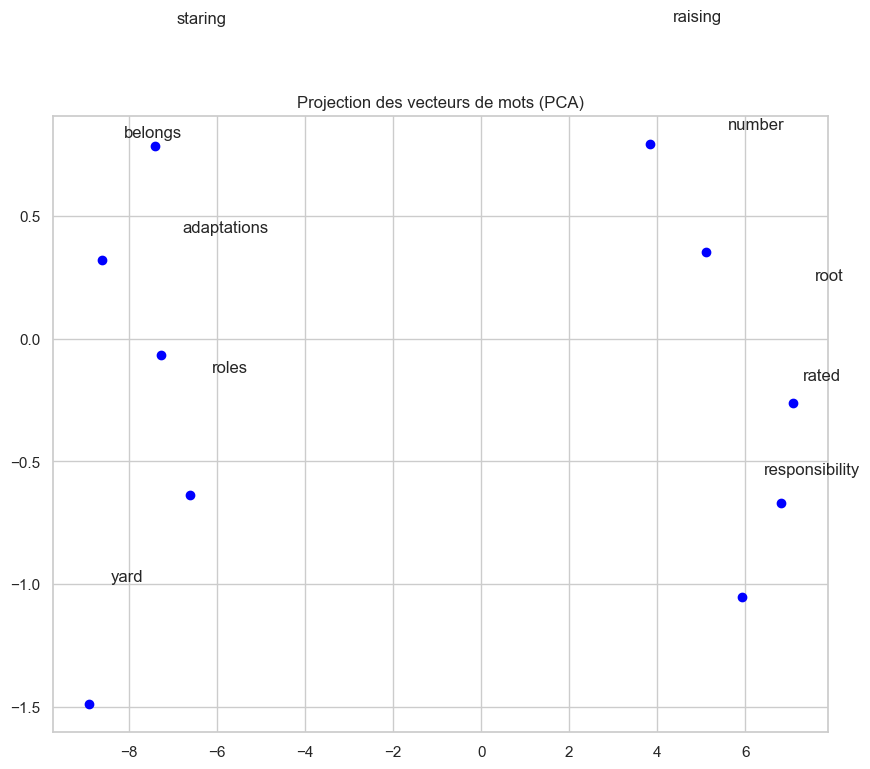

In [19]:
def plot_selected_words(words_to_plot):
    indices = [vocab[w] for w in words_to_plot if w in vocab]
    plt.figure(figsize=(10, 8))
    for idx in indices:
        plt.scatter(reduced_vecs[idx, 0], reduced_vecs[idx, 1], color='blue')
        plt.text(reduced_vecs[idx, 0]+0.5, reduced_vecs[idx, 1]+0.5, words[idx], fontsize=12)
    plt.title("Projection des vecteurs de mots (PCA)")
    plt.grid(True)
    plt.show()

# Exemple de mots sentimentaux à visualiser
positive_words = ["amazing", "great", "wonderful", "love", "best"]
negative_words = ["terrible", "bad", "awful", "boring", "worst"]

plot_selected_words(positive_words + negative_words)